In [1]:
!pip install astropy scikit-learn matplotlib tqdm

In [2]:
!pip install astropy

In [4]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os

folder = "/content/drive/MyDrive/continuum_data_subset"
os.listdir(folder)

['planet0_00226_1250.fits',
 'planet100_00580_1250.fits',
 'planet10_00710_1250.fits',
 'planet10_00816_1250.fits',
 'planet1_00490_1250.fits',
 'planet101_00972_1250.fits',
 'planet101_00988_1250.fits',
 'planet102_00142_1250.fits',
 'planet102_00188_1250.fits',
 'planet102_00222_1250.fits',
 'planet102_00230_1250.fits',
 'planet102_00346_1250.fits',
 'planet103_00510_1250.fits',
 'planet103_00718_1250.fits',
 'planet11_00010_1250.fits',
 'planet11_00700_1250.fits',
 'planet11_00886_1250.fits',
 'planet13_00098_1250.fits',
 'planet13_00302_1250.fits',
 'planet13_00324_1250.fits',
 'planet14_00314_1250.fits',
 'planet14_00528_1250.fits',
 'planet14_00804_1250.fits',
 'planet14_00914_1250.fits',
 'planet15_00186_1250.fits',
 'planet16_00614_1250.fits',
 'planet17_00162_1250.fits',
 'planet17_00506_1250.fits',
 'planet17_00648_1250.fits',
 'planet18_00114_1250.fits',
 'planet18_00942_1250.fits',
 'planet18_00992_1250.fits',
 'planet19_00914_1250.fits',
 'planet20_00230_1250.fits',
 'plan

In [7]:
import os
drive_root = '/content/drive/MyDrive/'
print(os.listdir(drive_root))

['ADS AI&DS II-I AI&DS', 'IMG-20250702-WA0005.jpg', 'IMG-20250729-WA0014.jpg', 'IMG-20250729-WA0012.jpg', 'IMG-20250729-WA0015.jpg', '1753798209333642185579855428346.jpg', 'adhar.pdf', 'inter.pdf', '10th.pdf', 'Classroom', 'Untitled document (3).gdoc', 'Colab Notebooks', 'IMG-20260203-WA0022 (1).jpg', 'IMG-20260203-WA0022.jpg', 'Screenshot_20260204-140442.png', 'Untitled document (2).gdoc', 'inbound4973718645441861979.pdf', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'powerbi (1)-compressed.pdf', 'rith (1)-compressed.pdf', 'accenture.pdf', 'codespark.pdf', 'pdf.pdf', 'wadhwani.pdf', 'hackathon.pdf', 'esdp (1).pdf', 'esdp.pdf', 'iic.pdf', 'innowave.pdf', 'powerbi (1).pdf', 'powerbi.pdf', 'gemini.pdf', 'html (1).pdf', 'continuum_data_subset']


In [15]:
from astropy.io import fits
import numpy as np
import os

images = []

for file in os.listdir(folder):
    if file.endswith(".fits"):
        path = os.path.join(folder, file)
        hdul = fits.open(path)

        image = hdul[0].data[0][0]   # important change

        images.append(image)

        hdul.close()

images = np.array(images)

print("Dataset shape:", images.shape)

Dataset shape: (150, 1, 600, 600)


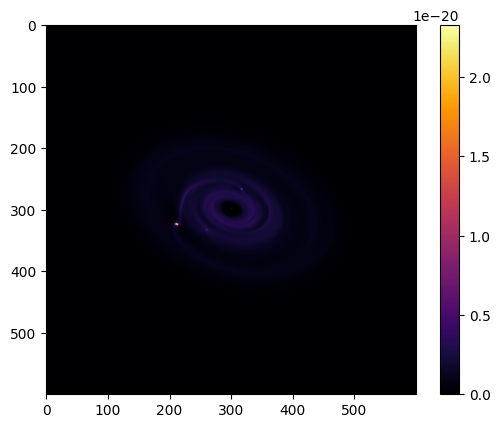

In [17]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

file_path = folder + "/planet0_00226_1250.fits"

hdul = fits.open(file_path)
# Assuming the image data is in the first HDU and needs slicing to be 2D
# Based on the error, the shape is (4, 1, 1, 600, 600), so we take the first 600x600 array
image = hdul[0].data[0, 0, 0, :, :]

plt.imshow(image, cmap='inferno')
plt.colorbar()
plt.show()

hdul.close()

In [18]:
n_samples = images.shape[0]

X = images.reshape(n_samples, -1)

print("Flattened shape:", X.shape)

Flattened shape: (150, 360000)


In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_reduced = pca.fit_transform(X)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (150, 50)


In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_reduced)

print("Cluster labels:", clusters)

Cluster labels: [1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 0 0 0 0 0 0 0 0 1 0 0 2
 0 0 0 1 2 0 4 1 0 0 0 3 1 0 0 0 2 0 0 0 2 0 0 2 2 0 0 2 0 0 1 0 0 0 2 2 0
 0 0 0 0 2 0 0 2 0 0 0 2 0 0 0 0 2 2 0 0 0 1 3 3 0 0 1 1 1 0 0 4 0 1 1 0 0
 2 0 2 3 2 3 0 2 2 1 1 2 3 1 1 1 1 2 2 2 2 2 2 0 0 1 1 1 3 4 4 0 0 2 2 0 0
 2 2]


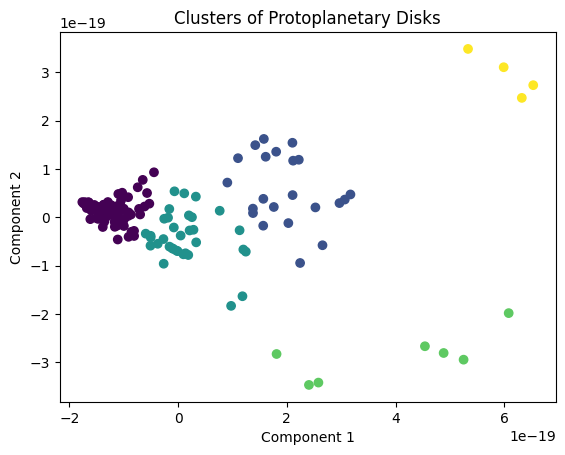

In [21]:
pca2 = PCA(n_components=2)

X_2d = pca2.fit_transform(X_reduced)

plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, cmap="viridis")

plt.title("Clusters of Protoplanetary Disks")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

Cluster 0


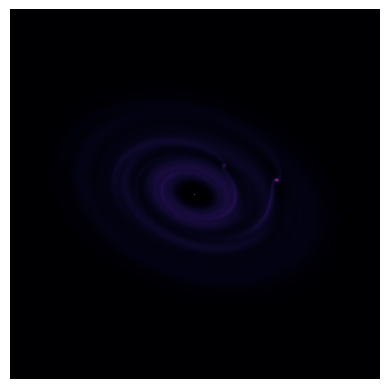

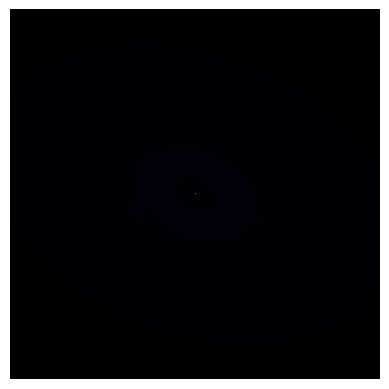

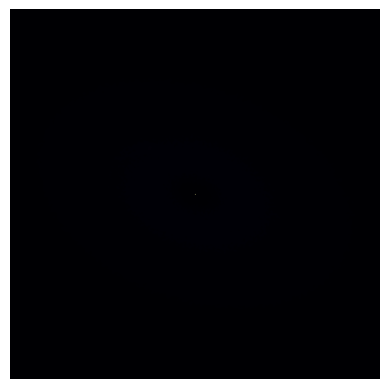

Cluster 1


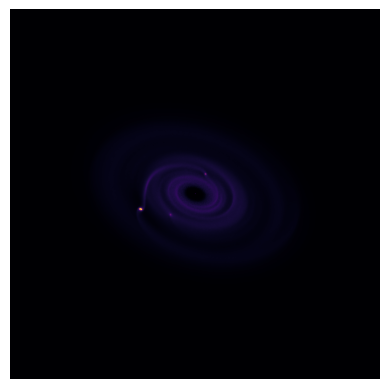

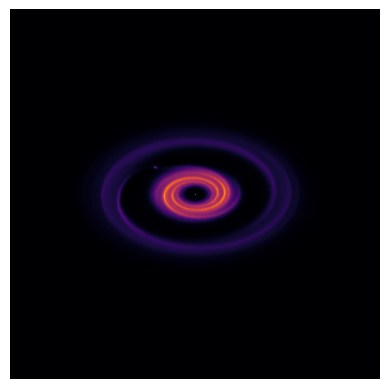

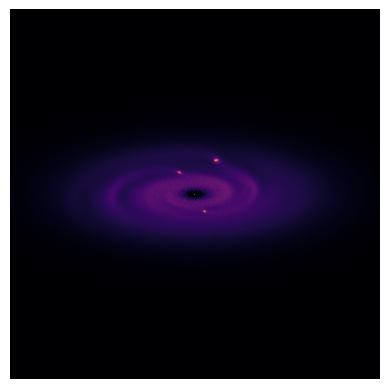

Cluster 2


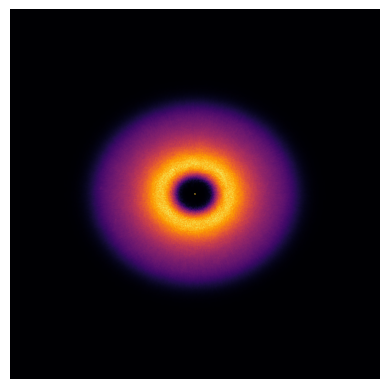

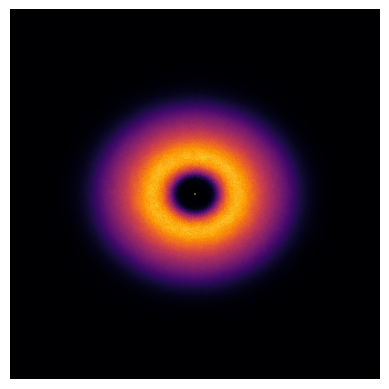

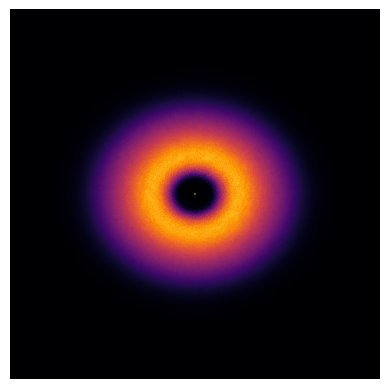

Cluster 3


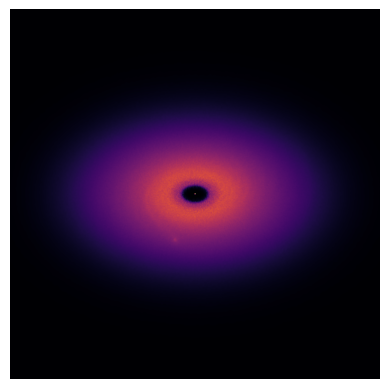

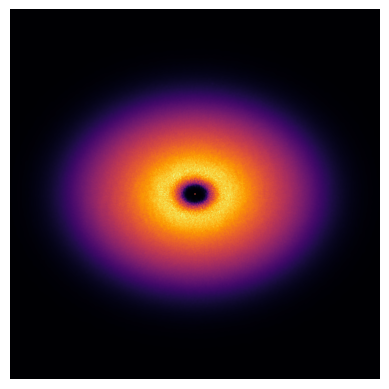

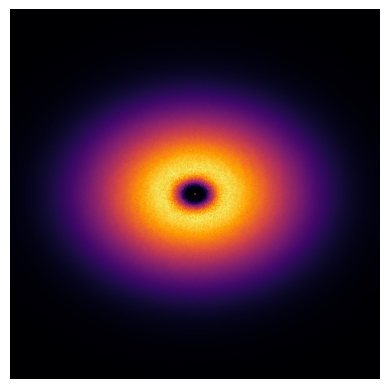

Cluster 4


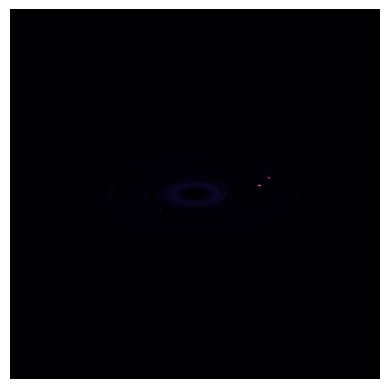

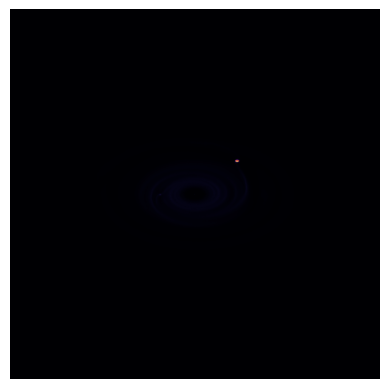

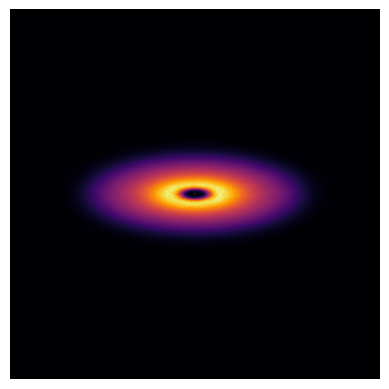

In [23]:
for cluster in range(5):

    idx = np.where(clusters == cluster)[0][:3]

    print("Cluster", cluster)

    for i in idx:
        plt.imshow(images[i].squeeze(), cmap="inferno")
        plt.axis("off")
        plt.show()